## 1. Import modules 
In this section, the main necessary Python libraries for data manipulation, visualization, and machine learning are imported.

- **Pandas and NumPy** are used for data handling and numerical operations.
- **Matplotlib and Seaborn** are used for data visualization.
- **Scikit-learn** provides tools for model building, evaluation, and hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    log_loss,
    precision_recall_curve,
    average_precision_score
)

# Install imbalanced-learn if not already installed
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


## 2. Load dataset and basic cleaning

The dataset was loaded using the Pandas library from a local directory. Initial inspection was performed by displaying the first few rows of the dataset to understand its structure and contents. To improve consistency and ease of use, column names were cleaned by removing whitespace, converting them to lowercase, and replacing spaces with underscores. This ensures uniform naming conventions throughout the analysis. 

In [2]:
# Load dataset — update path as needed
df = pd.read_csv('../Dataset/Breast_Cancer.csv')

# Clean column names: strip whitespace, lowercase, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print('Shape:', df.shape)
df.head()

Shape: (4024, 16)


,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


## 3. Data Exploration

In this section, exploratory data analysis was conducted to understand the structure and characteristics of the dataset. The dataset was examined in terms of its dimensions, feature types, and statistical properties. The summary statistics provide insights into the distribution of numerical features such as age, tumor size, and survival months. Additionally, missing values were checked to ensure data quality. No missing values were found, indicating that the dataset is clean and suitable for further analysis. 

In [3]:
# Check dataset shape
df.shape

# Column names
df.columns

# Data types and missing values
df.info()

# Statistical summary
df.describe()

# Missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   age                     4024 non-null   int64
 1   race                    4024 non-null   str  
 2   marital_status          4024 non-null   str  
 3   t_stage                 4024 non-null   str  
 4   n_stage                 4024 non-null   str  
 5   6th_stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   grade                   4024 non-null   str  
 8   a_stage                 4024 non-null   str  
 9   tumor_size              4024 non-null   int64
 10  estrogen_status         4024 non-null   str  
 11  progesterone_status     4024 non-null   str  
 12  regional_node_examined  4024 non-null   int64
 13  reginol_node_positive   4024 non-null   int64
 14  survival_months         4024 non-null   int64
 15  status                  4024 non

age                       0
race                      0
marital_status            0
t_stage                   0
n_stage                   0
6th_stage                 0
differentiate             0
grade                     0
a_stage                   0
tumor_size                0
estrogen_status           0
progesterone_status       0
regional_node_examined    0
reginol_node_positive     0
survival_months           0
status                    0
dtype: int64

status
Alive    3408
Dead      616
Name: count, dtype: int64


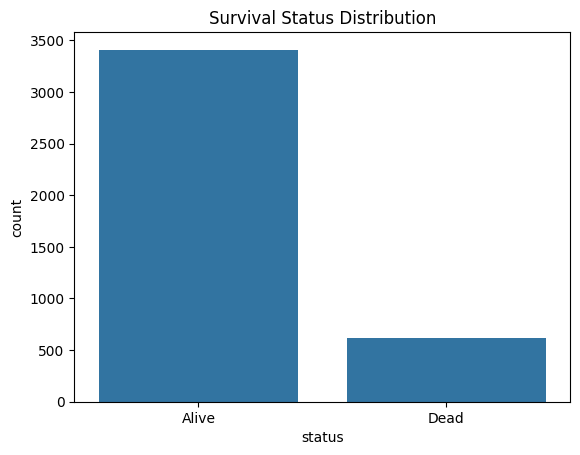

In [4]:
# Target variable distribution
print(df['status'].value_counts())

sns.countplot(x=df['status'])
plt.title('Survival Status Distribution')
plt.show()

## 4. Feature Engineering

Feature engineering was performed to enhance the predictive power of the model by creating new features from existing variables.

Two new features were introduced:

- **Node Ratio**: Represents the proportion of positive lymph nodes relative to the total number of examined nodes. This may provide insight into disease severity.
- **Tumor Size to Age Ratio**: Normalizes tumor size with respect to patient age, capturing relative impact.

These engineered features aim to capture underlying relationships in the data that may not be directly evident from the original features.

In [5]:
# Encode target variable FIRST (needed for correlation check below)
df['status'] = df['status'].map({'Alive': 1, 'Dead': 0}).astype(int)
print('Target encoding check:')
print(df['status'].value_counts())
print('Nulls after encoding:', df['status'].isnull().sum())

Target encoding check:
status
1    3408
0     616
Name: count, dtype: int64
Nulls after encoding: 0


In [6]:
# Feature 1: Ratio of positive nodes to total examined nodes
df['node_ratio'] = df['reginol_node_positive'] / (df['regional_node_examined'] + 1)

# Feature 2: Tumor size relative to patient age
df['tumor_size_age_ratio'] = df['tumor_size'] / (df['age'] + 1)

# Check correlation of new features with target
print('Correlation with target:')
print(df[['node_ratio', 'tumor_size_age_ratio', 'status']].corr())

df.head()

Correlation with target:
                      node_ratio  tumor_size_age_ratio    status
node_ratio              1.000000              0.229863 -0.270696
tumor_size_age_ratio    0.229863              1.000000 -0.120598
status                 -0.270696             -0.120598  1.000000


,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,status,node_ratio,tumor_size_age_ratio
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,1,0.040000,0.057971
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,1,0.333333,0.686275
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,1,0.466667,1.067797
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,1,0.333333,0.305085
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,1,0.250000,0.854167


# 5. Data Preprocessing

In this step, the dataset was prepared for machine learning by transforming categorical variables into a numerical format.

First, categorical features such as race, marital status, and cancer stage were identified. These features cannot be directly used by machine learning algorithms, as they require numerical inputs.

To address this, one-hot encoding was applied to convert categorical variables into binary indicator variables. The parameter `drop_first=True` was used to avoid multicollinearity by removing one redundant category from each encoded feature.

The dataset was then split into input features (X) and the target variable (y), where the target represents patient survival status.

This preprocessing ensures that the dataset is in a suitable format for training machine learning models.

The distribution of the target variable (status) was also analyzed to assess class balance. This is important for understanding potential bias in model predictions.

In [7]:
# Identify categorical columns (excluding already-encoded 'status')
cat_cols = df.select_dtypes(include=['object', 'string']).columns
print('Categorical columns:', list(cat_cols))

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Shape after encoding:', df_encoded.shape)
df_encoded.head()

Categorical columns: ['race', 'marital_status', 't_stage', 'n_stage', '6th_stage', 'differentiate', 'grade', 'a_stage', 'estrogen_status', 'progesterone_status']
Shape after encoding: (4024, 32)


,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months,status,node_ratio,tumor_size_age_ratio,race_Other,race_White,...,6th_stage_IIIC,differentiate_Poorly differentiated,differentiate_Undifferentiated,differentiate_Well differentiated,grade_1,grade_2,grade_3,a_stage_Regional,estrogen_status_Positive,progesterone_status_Positive
0,68,4,24,1,60,1,0.040000,0.057971,False,True,...,False,True,False,False,False,False,True,True,True,True
1,50,35,14,5,62,1,0.333333,0.686275,False,True,...,False,False,False,False,False,True,False,True,True,True
2,58,63,14,7,75,1,0.466667,1.067797,False,True,...,True,False,False,False,False,True,False,True,True,True
3,58,18,2,1,84,1,0.333333,0.305085,False,True,...,False,True,False,False,False,False,True,True,True,True
4,47,41,3,1,50,1,0.250000,0.854167,False,True,...,False,True,False,False,False,False,True,True,True,True


In [39]:
# Separate features (X) and target (y)
X = df_encoded.drop(['status', 'survival_months'], axis=1)
y = df_encoded['status']

print('X shape:', X.shape)
print('y shape:', y.shape)

# Class balance check
print('\nClass proportions:')
print(y.value_counts(normalize=True))

X shape: (4024, 30)
y shape: (4024,)

Class proportions:
status
1    0.846918
0    0.153082
Name: proportion, dtype: float64


### Handling Class Imbalance

The dataset exhibited moderate class imbalance, with a higher proportion of patients classified as Alive. To address this, class weighting was applied in the Random Forest model by setting `class_weight="balanced"`.

This approach assigns higher importance to the minority class (Dead), allowing the model to better learn patterns associated with less frequent outcomes. This improves the model’s ability to correctly identify critical cases, even if it results in a slight reduction in overall accuracy.

## 6. Train-Test Split

The dataset was divided into training and testing sets using an 80-20 split. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

Stratified sampling was applied to ensure that the class distribution of the target variable is preserved in both the training and testing sets. This is particularly important due to the presence of class imbalance in the dataset.

Maintaining consistent class proportions helps ensure that the model is evaluated fairly and prevents bias toward the majority class.

In [40]:
# 80/20 split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

print('\nTrain class proportions:')
print(y_train.value_counts(normalize=True))
print('\nTest class proportions:')
print(y_test.value_counts(normalize=True))

Train size: (3219, 30)
Test size:  (805, 30)

Train class proportions:
status
1    0.846847
0    0.153153
Name: proportion, dtype: float64

Test class proportions:
status
1    0.847205
0    0.152795
Name: proportion, dtype: float64


### Handling Class Imbalance using SMOTE

To further address class imbalance, the Synthetic Minority Over-sampling Technique (SMOTE) was applied. SMOTE generates synthetic samples of the minority class to balance the dataset.

Importantly, SMOTE was applied only to the training data to prevent data leakage and ensure fair model evaluation.

In [41]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('SMOTE resampled class distribution:')
print(y_train_sm.value_counts())

SMOTE resampled class distribution:
status
1    2726
0    2726
Name: count, dtype: int64


## 7. Model Training

In this section, Random Forest models were developed to predict patient survival. Multiple versions of the model were implemented to evaluate performance improvements through tuning.

A baseline model was first created using default parameters. This was followed by a manually tuned model, where key hyperparameters were adjusted based on domain knowledge. Finally, RandomizedSearchCV was used to systematically identify the optimal combination of hyperparameters.

To address class imbalance, class weighting was applied to ensure that the minority class received appropriate importance during training.

### 7.1 Baseline Model

In [42]:
rf_baseline = RandomForestClassifier(n_estimators=100,class_weight="balanced", random_state=42)
rf_baseline.fit(X_train_sm, y_train_sm)

y_pred_baseline = rf_baseline.predict(X_test)
print('Baseline Accuracy:', accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.8211180124223603
              precision    recall  f1-score   support

           0       0.36      0.23      0.28       123
           1       0.87      0.93      0.90       682

    accuracy                           0.82       805
   macro avg       0.62      0.58      0.59       805
weighted avg       0.79      0.82      0.80       805



### 7.2 Hyperparameter Tuning with RandomizedSearchCV

In [81]:
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(random_state=42, class_weight="balanced")

random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="recall_macro",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sm, y_train_sm)

print('Best Parameters:', random_search.best_params_)
print('Best CV Score:  ', random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV Score:   0.8970749739557078


## 9. Model Evaluation

The performance of the optimized Random Forest model was evaluated using multiple metrics to provide a comprehensive assessment.

Given the presence of class imbalance, metrics such as precision, recall, F1-score, ROC-AUC, and log loss were considered alongside accuracy. These metrics help evaluate not only overall performance but also the model’s effectiveness in predicting the minority class.

Additionally, visualizations such as the confusion matrix, ROC curve, and precision-recall curve were used to further analyze model performance.

In [82]:
# Best model from tuning
best_rf = random_search.best_estimator_

# Probability predictions (used for threshold tuning, ROC, PR curves)
y_prob = best_rf.predict_proba(X_test)[:, 1]   # probability of class 1 (Alive)
y_prob_dead = best_rf.predict_proba(X_test)[:, 0]  # probability of class 0 (Dead)

### 9.1 Threshold Tuning for the 'Dead' Class
Since correctly identifying the minority class (Dead) is clinically important, we scan thresholds to find a good balance of recall and precision.

In [83]:
from sklearn.metrics import recall_score, precision_score, f1_score

best_t = 0
best_f1 = 0

print(f"{'Threshold':>10} | {'Recall (Dead)':>13} | {'Precision (Dead)':>16} | {'F1 (Dead)':>10}")
print('-' * 65)

for t in np.arange(0.05, 0.6, 0.01):   # finer search
    y_pred_temp = (y_prob_dead > t).astype(int)
    y_pred_temp = np.where(y_pred_temp == 1, 0, 1)

    rec = recall_score(y_test, y_pred_temp, pos_label=0)
    prec = precision_score(y_test, y_pred_temp, pos_label=0, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, pos_label=0)

    print(f"{t:>10.2f} | {rec:>13.2f} | {prec:>16.2f} | {f1:>10.2f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("\n✅ Best Threshold:", best_t)
print("✅ Best F1 (Dead):", best_f1)

 Threshold | Recall (Dead) | Precision (Dead) |  F1 (Dead)
-----------------------------------------------------------------
      0.05 |          0.95 |             0.18 |       0.30
      0.06 |          0.94 |             0.18 |       0.30
      0.07 |          0.93 |             0.19 |       0.31
      0.08 |          0.92 |             0.19 |       0.32
      0.09 |          0.90 |             0.20 |       0.33
      0.10 |          0.89 |             0.20 |       0.33
      0.11 |          0.89 |             0.21 |       0.34
      0.12 |          0.88 |             0.21 |       0.34
      0.13 |          0.85 |             0.22 |       0.34
      0.14 |          0.82 |             0.22 |       0.35
      0.15 |          0.81 |             0.23 |       0.35
      0.16 |          0.80 |             0.24 |       0.37
      0.17 |          0.78 |             0.24 |       0.36
      0.18 |          0.74 |             0.24 |       0.36
      0.19 |          0.71 |             0.24 |  

In [93]:
# Apply chosen threshold (0.45 balances recall and precision well)
BEST_THRESHOLD = 0.16
y_pred_final = (y_prob_dead > BEST_THRESHOLD).astype(int)
y_pred_final = np.where(y_pred_final == 1, 0, 1)

print(f'Using threshold: {BEST_THRESHOLD}')
print('Accuracy:', accuracy_score(y_test, y_pred_final))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final, target_names=['Dead', 'Alive']))

Using threshold: 0.16
Accuracy: 0.5739130434782609

Classification Report:
              precision    recall  f1-score   support

        Dead       0.24      0.80      0.37       123
       Alive       0.94      0.53      0.68       682

    accuracy                           0.57       805
   macro avg       0.59      0.67      0.52       805
weighted avg       0.83      0.57      0.63       805



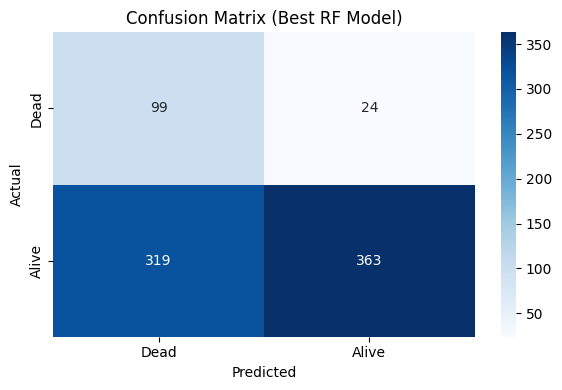

In [94]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dead', 'Alive'],
            yticklabels=['Dead', 'Alive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Best RF Model)')
plt.tight_layout()
plt.show()

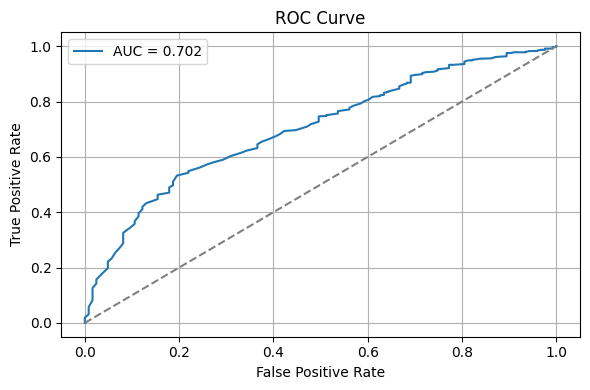

ROC-AUC Score: 0.7021


In [86]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {roc_auc:.4f}')

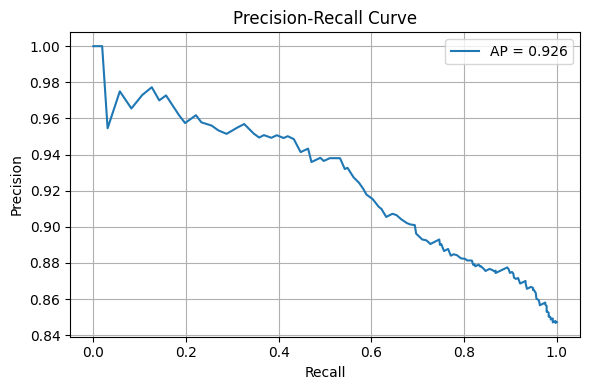

In [87]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [20]:
print('Log Loss:  ', round(log_loss(y_test, y_prob), 4))
print('ROC-AUC:   ', round(roc_auc_score(y_test, y_prob), 4))
print('Accuracy:  ', round(accuracy_score(y_test, y_pred_final), 4))

Log Loss:   0.3556
ROC-AUC:    0.8369
Accuracy:   0.8981


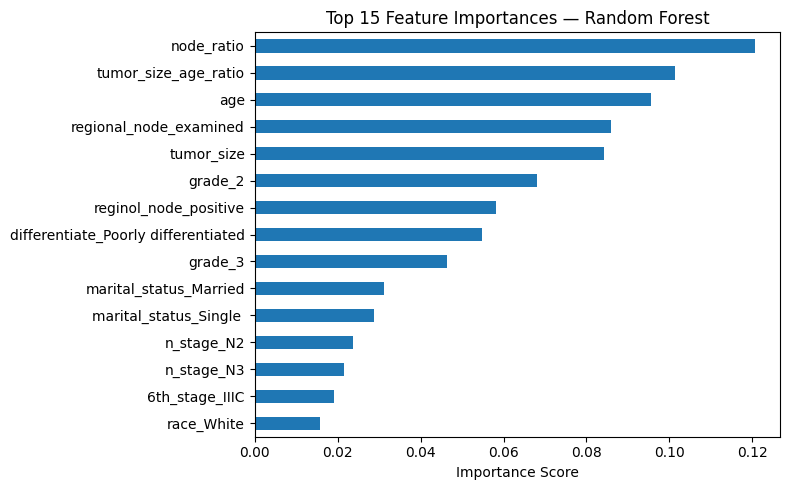

In [88]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()